# Point Cloud Clustering Analysis
## Complete workflow for clustering vineyard point cloud data

This notebook performs:
1. Loading point cloud data and understanding the coordinate system
2. 2D visualization of Z values (height map)
3. 3D visualization of original data
4. Statistical analysis of point distances
5. Clustering parameter recommendations
6. Running C++ clustering with multiple parameter sets
7. Visualization of clustering results

**Note:** Height-based filtering is currently commented out. All data points are used for analysis.

In [34]:
import laspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist
import subprocess
import os

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load Point Cloud Data
Using `las_to_dataframe` method from read_plot_voxelization.ipynb

In [37]:
import laspy
import pandas as pd
import numpy as np
import seaborn as sns
import open3d as o3d
import nbimporter
from read_plot_voxelization import  export_filtered_las, show_voxelgrid_plotly, point_cloud_to_dataframe

def plot_df_columns(cols, df):
    """
    Plots dataframe columns.
    """
    plt.figure(figsize=(14, 8))
    for i, col in enumerate(cols):
        plt.subplot(2, 3, i+1)
        sns.histplot(df[col], kde=True, bins=50, color='steelblue')
        plt.title(f'Distribution: {col}')
    plt.tight_layout()
    plt.show()


In [23]:
las_path = "./DATASOURCE/LOCAL_VINEYARD_MS.las"
scaleManually=True
# 1) raw integer koordinate (kao las.X)
filtered_df = point_cloud_to_dataframe(las_path)


# before = len(df)
# df = df[df["Z"] >= 38.5].reset_index(drop=True)
# after = len(df)

#print(f"Removed {before - after:,} points with Z < 40. Remaining: {after:,}")

print("x")
print(filtered_df.X.median())
print(filtered_df.X.mean())
print("y")
print(filtered_df.Y.median())
print(filtered_df.Y.mean())
print("z")
print(filtered_df.Z.median())
print(filtered_df.Z.mean())


📂 Loading LAS/LAZ file: ./DATASOURCE/LOCAL_VINEYARD_MS.las
Number of points: 18,557,364
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'nir', 'normal z', 'normal y', 'normal x', 'confidence']
DataFrame created. Shape: (18557364, 26)
x
23.516000000000076
23.14149867621285
y
25.759000000000015
25.699956253646757
z
39.903999999999996
39.877671849461


In [5]:
filtered_df.describe()

,X,Y,Z,intensity,return_number,number_of_returns,synthetic,key_point,withheld,overlap,...,point_source_id,gps_time,red,green,blue,nir,normal z,normal y,normal x,confidence
count,1.855736e+07,1.855736e+07,1.855736e+07,18557364.0,18557364.0,18557364.0,18557364.0,18557364.0,18557364.0,18557364.0,...,18557364.0,18557364.0,1.855736e+07,1.855736e+07,1.855736e+07,18557364.0,1.855736e+07,1.855736e+07,1.855736e+07,1.855736e+07
mean,2.314150e+01,2.569996e+01,3.987767e+01,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,9.963423e+03,1.118659e+04,8.542477e+03,0.0,7.476316e-01,2.415785e-02,-3.625448e-02,7.113346e+00
std,1.873971e+01,3.132712e+01,1.161230e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,9.675464e+03,7.956533e+03,6.703750e+03,0.0,2.797985e-01,3.640359e-01,4.659710e-01,5.076646e+00
min,-2.397200e+01,-3.736800e+01,3.729300e+01,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.560000e+02,2.560000e+02,2.560000e+02,0.0,-8.267717e-01,-9.921260e-01,-9.921260e-01,1.000000e+00
25%,9.393000e+00,-9.240000e-01,3.910200e+01,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.048000e+03,3.584000e+03,2.560000e+03,0.0,6.141732e-01,-1.732284e-01,-3.464567e-01,3.000000e+00
50%,2.351600e+01,2.575900e+01,3.990400e+01,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.120000e+03,1.100800e+04,7.680000e+03,0.0,8.582677e-01,2.362205e-02,-3.149606e-02,6.000000e+00
75%,3.711700e+01,5.237600e+01,4.061900e+01,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.740800e+04,1.612800e+04,1.228800e+04,0.0,9.685040e-01,2.283465e-01,2.677165e-01,1.000000e+01
max,6.774700e+01,9.051000e+01,4.272700e+01,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,6.528000e+04,6.528000e+04,6.528000e+04,0.0,9.921260e-01,9.921260e-01,9.921260e-01,3.100000e+01


In [10]:
# Load the LAZ file
laz_file = "./table_scene_lms400.pcd"
filtered_df = point_cloud_to_dataframe(laz_file)
print(f"\nDataFrame from PCL library example info:")
print(filtered_df.head())
print(f"\nColumns: {filtered_df.columns.tolist()}")

📂 Loading PCD file: ./table_scene_lms400.pcd
Number of points: 460,400
DataFrame created. Shape: (460400, 3)

DataFrame from PCL library example info:
         X        Y       Z
0 -0.93387 -0.68250 -1.1865
1 -0.93173 -0.68323 -1.1878
2 -0.92185 -0.68054 -1.1831
3 -0.91748 -0.67961 -1.1815
4 -0.91479 -0.67990 -1.1820

Columns: ['X', 'Y', 'Z']


In [11]:
las_path = "./DATASOURCE/LOCAL_VINEYARD_MS.las"
filtered_df = point_cloud_to_dataframe(las_path)

📂 Loading LAS/LAZ file: ./DATASOURCE/LOCAL_VINEYARD_MS.las
Number of points: 18,557,364
1064462
scales : [0.001 0.001 0.001]
offsets: [-1000. -1000.    30.]
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'nir', 'normal z', 'normal y', 'normal x', 'confidence']
DataFrame created. Shape: (18557364, 26)


## Understanding the Coordinate System

We focus on LOCAL_VINEYARD_MS datasource that after applying scale and offset factors contains data in meters. 

## 2D Visualization of Z Values

Visualize the height (Z) values of the point cloud in a 2D top-down view.  
For points with duplicate X,Y coordinates, we select the maximum Z value.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_z_values_2d(df, n_sample=100000, resolution_m=0.05):
    """
    Create a 2D top-down visualization of Z values (meters).
    For duplicate X,Y grid cells, pick the maximum Z value.
    
    Args:
        df: DataFrame with columns ['X','Y','Z'] in meters
        n_sample: max points to sample for speed (optional)
        resolution_m: grid cell size in meters (e.g., 0.05 = 5 cm)
    """
    print("Creating 2D Z-value visualization...")

    # Optional sampling for speed
    if n_sample is not None and len(df) > n_sample:
        sample = df.sample(n=n_sample, random_state=42).copy()
        print(f"  Sampled {n_sample:,} points from {len(df):,} total")
    else:
        sample = df.copy()

    # Quantize X,Y to grid resolution (meters)
    # floor(x/res)*res is robust for floats and works with negatives
    sample['X_grid'] = np.floor(sample['X'] / resolution_m) * resolution_m
    sample['Y_grid'] = np.floor(sample['Y'] / resolution_m) * resolution_m

    print(f"  Grouping points by {resolution_m:.4f} m grid...")
    z_max = sample.groupby(['X_grid', 'Y_grid'], as_index=False)['Z'].max()

    print(f"  Grid cells: {len(z_max):,}")
    print(f"  Z range: {z_max['Z'].min():.3f} to {z_max['Z'].max():.3f} m")

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Plot 1: Scatter plot with Z as color
    scatter1 = axes[0].scatter(
        z_max['X_grid'], z_max['Y_grid'],
        c=z_max['Z'], cmap='terrain',
        s=5, alpha=0.8, edgecolors='none'
    )
    axes[0].set_xlabel('X (m)', fontsize=12)
    axes[0].set_ylabel('Y (m)', fontsize=12)
    axes[0].set_title('2D Top-Down View (Z as Color)\nMax Z per grid cell', fontsize=14)
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0], label='Z (m)', pad=0.02)

    # Plot 2: Z-value histogram
    axes[1].hist(z_max['Z'], bins=100, alpha=0.7, edgecolor='black')
    axes[1].axvline(z_max['Z'].mean(), linestyle='--', linewidth=2,
                    label=f"Mean: {z_max['Z'].mean():.3f} m")
    axes[1].axvline(z_max['Z'].median(), linestyle='--', linewidth=2,
                    label=f"Median: {z_max['Z'].median():.3f} m")
    axes[1].set_xlabel('Z (m)', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title('Z Value Distribution\n(Height histogram)', fontsize=14)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Print statistics (meters)
    print("\n=== Z-VALUE STATISTICS (m) ===")
    print(f"Mean Z:   {z_max['Z'].mean():.4f} m")
    print(f"Median Z: {z_max['Z'].median():.4f} m")
    print(f"Std Dev:  {z_max['Z'].std():.4f} m")
    print(f"Min Z:    {z_max['Z'].min():.4f} m")
    print(f"Max Z:    {z_max['Z'].max():.4f} m")
    print(f"Range:    {(z_max['Z'].max() - z_max['Z'].min()):.4f} m")

    return z_max



Creating 2D Z-value visualization...
  Sampled 100,000 points from 18,557,364 total
  Grouping points by 0.0500 m grid...
  Grid cells: 97,118
  Z range: 37.309 to 42.608 m


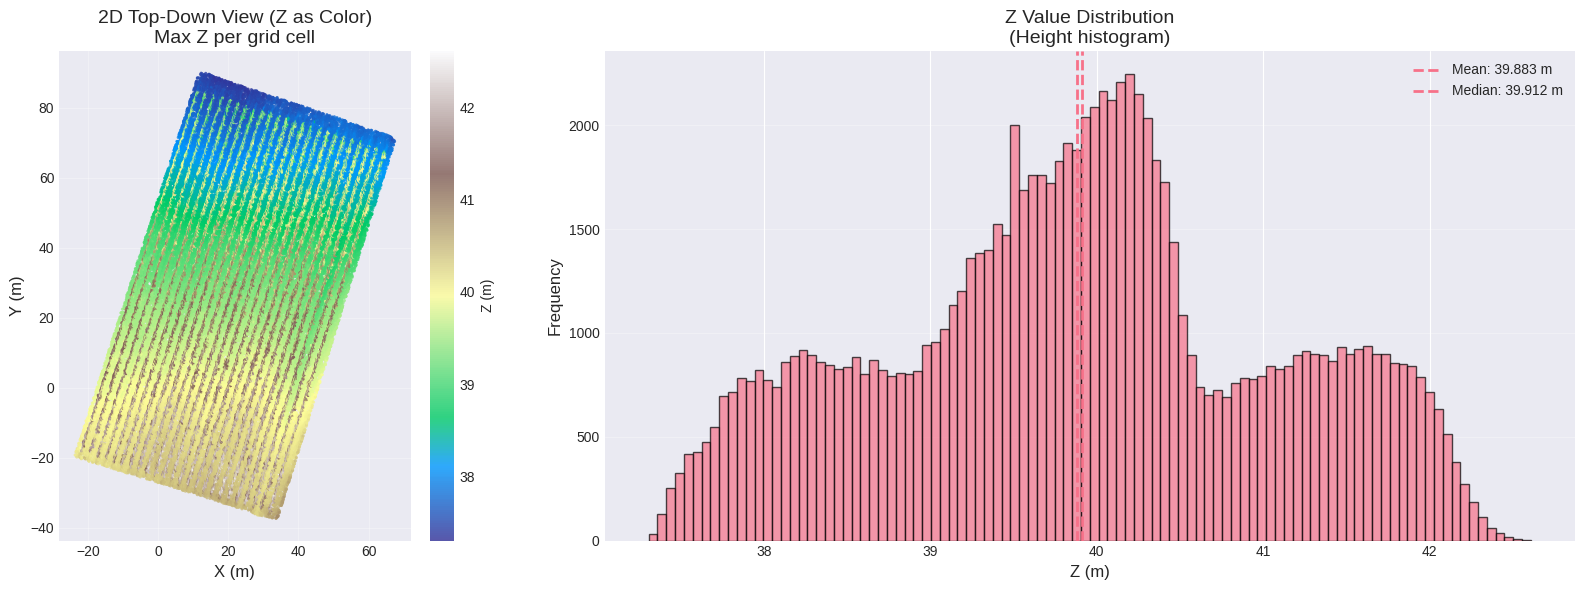


=== Z-VALUE STATISTICS (m) ===
Mean Z:   39.8827 m
Median Z: 39.9120 m
Std Dev:  1.1646 m
Min Z:    37.3090 m
Max Z:    42.6080 m
Range:    5.2990 m


In [25]:
# Example call: 5 cm grid
z_values_2d = visualize_z_values_2d(filtered_df, n_sample=100000, resolution_m=0.05)

## 3. Visualize Point Cloud - Method 1: Matplotlib

Sampling 900,000 points for visualization


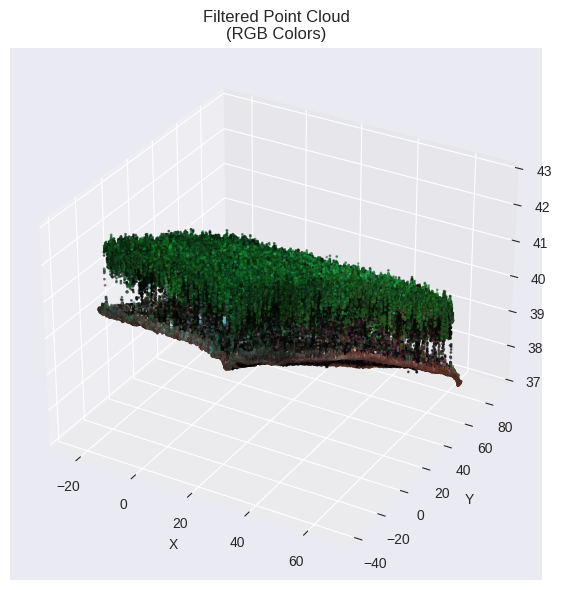

In [16]:
def visualize_point_cloud_matplotlib(df, n_sample=900000, title="Point Cloud Visualization"):
    """
    Visualize point cloud using matplotlib 3D scatter.
    """
    #Sample for performance
    if len(df) > n_sample:
        sample = df.sample(n=n_sample, random_state=42)
        print(f"Sampling {n_sample:,} points for visualization")
    else:
        sample = df

    fig = plt.figure(figsize=(15, 6))
    
    # # Plot 1: Colored by height - only works for LIDAR data
    
    # ax1 = fig.add_subplot(121, projection='3d')
    # scatter1 = ax1.scatter(sample["X"], sample["Y"], sample["Z"], 
    #                       c=sample["height above ground"], 
    #                       cmap='viridis', s=1, alpha=0.6)
    # ax1.set_xlabel('X')
    # ax1.set_ylabel('Y')
    # ax1.set_zlabel('Z')
    # ax1.set_title(f'{title}\n(Colored by Height Above Ground)')
    # plt.colorbar(scatter1, ax=ax1, label='Height (m)', pad=0.1)
    
    # Plot 2: Colored by RGB
    ax2 = fig.add_subplot(122, projection='3d')
    if 'red' in sample.columns and 'green' in sample.columns and 'blue' in sample.columns:
        colors_rgb = np.column_stack([
            sample['red'].values / 65535.0,
            sample['green'].values / 65535.0,
            sample['blue'].values / 65535.0
        ])
        ax2.scatter(sample["X"], sample["Y"], sample["Z"], 
                   c=colors_rgb, s=1, alpha=0.6)
    else:
        ax2.scatter(sample["X"], sample["Y"], sample["Z"], 
                   c='blue', s=1, alpha=0.6)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_title(f'{title}\n(RGB Colors)')
    
    plt.tight_layout()
    plt.show()

# Visualize filtered data
visualize_point_cloud_matplotlib(filtered_df, title="Filtered Point Cloud")

## 4. Visualize Point Cloud - Method 2: Using plot_point_cloud_points

In [49]:
#from read_plot_voxelization import  plot_df_columns, plot_point_cloud_points, point_cloud_to_dataframe, _las_to_dataframe
#doesn't work for some reason

In [45]:

def point_cloud_to_dataframe(
    file_path: str,
    apply_scale: bool = True) -> pd.DataFrame:
    file_ext = file_path.lower().split('.')[-1]
    
    if file_ext in ['las', 'laz']:
        return _las_to_dataframe(file_path, apply_scale=apply_scale)  
    elif file_ext == 'pcd':
        return _
    else:
        raise ValueError(f"Unsupported file format: .{file_ext}. Supported: .las, .laz, .pcd")

In [56]:

def _las_to_dataframe(las_path: str, apply_scale: bool = True) -> pd.DataFrame:
    """
    Loads .las/.laz file and converts it to a pandas DataFrame.
    """
    print(f"📂 Loading LAS/LAZ file: {las_path}")
    las = laspy.read(las_path)

    print(f"Number of points: {las.header.point_count:,}")

    dims = [dim.name for dim in las.point_format.dimensions]
    print(f"Detected dimensions: {dims}")

    data = {}
    for dim in dims:
        try:
            arr = getattr(las, dim)
            data[dim] = np.array(arr)
        except AttributeError:
            print(f"Field '{dim}' is not found.")
            continue

    df = pd.DataFrame(data)
    if apply_scale:
        sx, sy, sz = las.header.scales
        ox, oy, oz = las.header.offsets

        print(f"Scales  (sx, sy, sz): {sx}, {sy}, {sz}")
        print(f"Offsets (ox, oy, oz): {ox}, {oy}, {oz}")

        if "X" in df.columns:
            df["X"] = df["X"].astype(np.float64) * 1/1000 
        if "Y" in df.columns:
            df["Y"] = df["Y"].astype(np.float64) * 1/1000 
        if "Z" in df.columns:
            df["Z"] = df["Z"].astype(np.float64) * 1/1000 + oz

        print("Applied LAS header scale+offset to X,Y,Z.")
    else:
        print("Kept raw LAS X,Y,Z (no header scale+offset applied).")
    
    print(f"DataFrame created. Shape: {df.shape}")
    return df

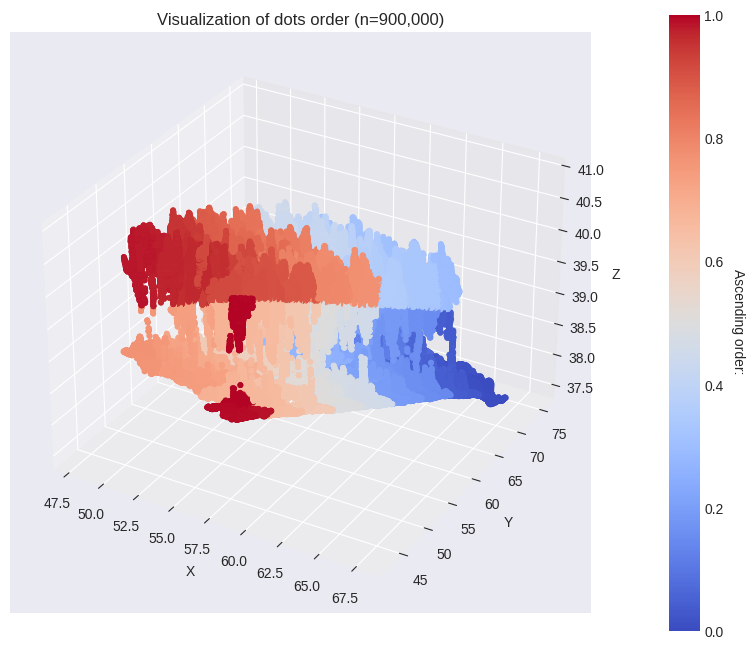

In [50]:
# Visualize with custom function
plot_point_cloud_points(filtered_df, n_points=900000)

## 5. Distance Analysis
Analyze point-to-point distances to determine optimal clustering parameters
When I substitute value 1067276 with some neighbor that has value 1067442 I got 175. And this 175 represent milimeters.


### Key Takeaways from PCL Tutorial

Algorithm (flood-fill style):

Build KD-tree for fast neighbor search

For each unprocessed point, find all neighbors within clusterTolerance radius

Recursively add their neighbors until no more points within tolerance

That's one cluster — repeat for remaining points

In [57]:
las_path = "./DATASOURCE/RemovedGroundExtracted_vineyard_SCALED.las"

df = point_cloud_to_dataframe(las_path, apply_scale=True)  

print(df.head())
print(df.columns)

📂 Loading LAS/LAZ file: ./DATASOURCE/RemovedGroundExtracted_vineyard_SCALED.las
Number of points: 11,500,691
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue', 'nir', 'beam id', 'height above ground', 'distance']
Scales  (sx, sy, sz): 0.001, 0.001, 0.001
Offsets (ox, oy, oz): 273484.0, 5018700.0, 36.361
Applied LAS header scale+offset to X,Y,Z.
DataFrame created. Shape: (11500691, 25)
        X       Y       Z  intensity  return_number  number_of_returns  \
0  66.504  62.020  37.696       1024              1                  2   
1  66.589  63.896  37.289       2048              1                  2   
2  66.630  63.868  37.571       6144              1                  1   
3  66.685  64.005  37.225       2048              1              

Analyzing distances for 18,557,364 points...
Using 900,000 sampled points for distance analysis

Calculating nearest neighbor distances...

=== DISTANCE STATISTICS (meters) ===
Mean nn distance:   0.1033 m
Min nn distance:    0.0110 m
Median nn distance: 0.0996 m
Std dev:            0.0316 m

Percentiles:
  25th: 0.0824 m
  50th: 0.0996 m
  75th: 0.1194 m
  90th: 0.1404 m
  95th: 0.1553 m


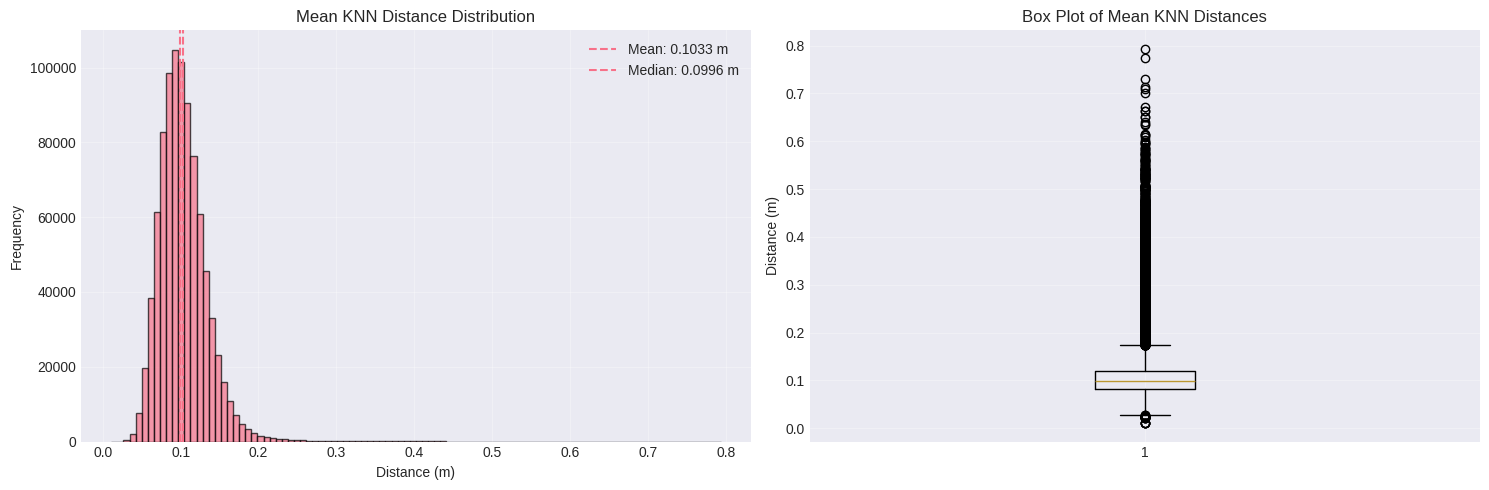

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

def analyze_point_distances(df, n_sample=900000, k_neighbors=6):
    """
    Analyze distances between points to help choose clustering parameters.
    Assumes df[['X','Y','Z']] are in METERS (so distances are meters).
    
    Args:
        df: pandas DataFrame with X,Y,Z in meters
        n_sample: subsample size for speed
        k_neighbors: number of neighbors (including self) for knn query
                    (e.g., 6 -> 5 real neighbors used)
    Returns:
        mean_nn_dist: array of per-point mean distance to neighbors (meters)
    """
    print(f"Analyzing distances for {len(df):,} points...")

    # Sample for performance
    if len(df) > n_sample:
        sample = df.sample(n=n_sample, random_state=42).copy()
        print(f"Using {n_sample:,} sampled points for distance analysis")
    else:
        sample = df.copy()

    points = sample[["X", "Y", "Z"]].to_numpy(dtype=np.float64)

    print("\nCalculating nearest neighbor distances...")
    nbrs = NearestNeighbors(n_neighbors=k_neighbors, algorithm='kd_tree').fit(points)
    distances, _ = nbrs.kneighbors(points)

    # distances[:,0] is 0 (self). Use the rest.
    nn_distances = distances[:, 1:]
    mean_nn_dist = nn_distances.mean(axis=1)

    # Statistics (meters)
    print("\n=== DISTANCE STATISTICS (meters) ===")
    print(f"Mean nn distance:   {mean_nn_dist.mean():.4f} m")
    print(f"Min nn distance:    {mean_nn_dist.min():.4f} m")
    print(f"Median nn distance: {np.median(mean_nn_dist):.4f} m")
    print(f"Std dev:            {mean_nn_dist.std():.4f} m")

    print("\nPercentiles:")
    for p in [25, 50, 75, 90, 95]:
        print(f"  {p:>2}th: {np.percentile(mean_nn_dist, p):.4f} m")

    # Plot distribution: histogram + boxplot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].hist(mean_nn_dist, bins=100, alpha=0.7, edgecolor='black')
    axes[0].axvline(mean_nn_dist.mean(), linestyle='--', label=f"Mean: {mean_nn_dist.mean():.4f} m")
    axes[0].axvline(np.median(mean_nn_dist), linestyle='--', label=f"Median: {np.median(mean_nn_dist):.4f} m")
    axes[0].set_xlabel("Distance (m)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Mean KNN Distance Distribution")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].boxplot(mean_nn_dist, vert=True)
    axes[1].set_ylabel("Distance (m)")
    axes[1].set_title("Box Plot of Mean KNN Distances")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return mean_nn_dist

# Run distance analysis
distances = analyze_point_distances(filtered_df, n_sample=900000, k_neighbors=6)

## 6. Clustering Parameter Recommendations - INVALID, common sense works better currently

In [ ]:
import numpy as np

def recommend_clustering_parameters(distances_m):
    """
    Recommend clustering parameters based on distance analysis.
    Input distances are in METERS, output tolerance is in METERS (ready for PCL/C++).
    """
    mean_dist = float(np.mean(distances_m))
    median_dist = float(np.median(distances_m))
    p75 = float(np.percentile(distances_m, 75))
    p90 = float(np.percentile(distances_m, 90))

    print("\n" + "="*70)
    print("CLUSTERING PARAMETER RECOMMENDATIONS (meters)")
    print("="*70)

    print("\nBased on distance analysis, here are three recommended parameter sets:")
    print("(Distances computed in meters; tolerance returned in meters for C++/PCL)\n")

    # Conservative (tight clusters) - tolerance in meters
    tolerance_tight = median_dist * 1.5
    print("1. CONSERVATIVE (Tight Clusters):")
    print(f"   - cluster_tolerance: {tolerance_tight:.4f} m")
    print("   - min_cluster_size: 200")
    print("   - Rationale: 1.5x median distance, strict grouping")
    print("   - Expected: Many small clusters, high precision\n")

    # Moderate (balanced) - tolerance in meters
    tolerance_moderate = p75 * 1.2
    print("2. MODERATE (Balanced):")
    print(f"   - cluster_tolerance: {tolerance_moderate:.4f} m")
    print("   - min_cluster_size: 150")
    print("   - Rationale: 1.2x 75th percentile, balanced approach")
    print("   - Expected: Medium-sized clusters, good balance\n")

    # Aggressive (loose clusters) - tolerance in meters
    tolerance_loose = p90 * 1.5
    print("3. AGGRESSIVE (Loose Clusters):")
    print(f"   - cluster_tolerance: {tolerance_loose:.4f} m")
    print("   - min_cluster_size: 100")
    print("   - Rationale: 1.5x 90th percentile, group more points")
    print("   - Expected: Fewer large clusters, captures more variation\n")

    print("="*70)

    # NOTE: PCL uses the same unit as your input point cloud.
    # If your cloud is in meters, these tolerances are correct as-is.
    params = {
        "conservative": {"tolerance": tolerance_tight,    "min_size": 200, "max_size": 25000},
        "moderate":     {"tolerance": tolerance_moderate, "min_size": 150, "max_size": 1000000},
        "aggressive":   {"tolerance": tolerance_loose,    "min_size": 100, "max_size": 1000000},
    }

    return params


# Get recommendations (distances already in meters)
clustering_params = recommend_clustering_parameters(distances)


## 7. Save Filtered Point Cloud for C++ Processing

In [64]:
def save_point_cloud(df: pd.DataFrame, output_path: str, original_las_path: str = None) -> None:
    """
    Save a DataFrame to a point cloud file (.las, .laz, or .pcd).
    Automatically detects file type based on extension.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with at least X, Y, Z columns
    output_path : str
        Path for output file (.las, .laz, or .pcd)
    original_las_path : str, optional
        Path to original LAS file (required for LAS/LAZ output to copy header info)
    """
    file_ext = output_path.lower().split('.')[-1]
    
    if file_ext in ['las', 'laz']:
        if original_las_path is None:
            raise ValueError("original_las_path is required when saving to LAS/LAZ format")
        _save_as_las(df, output_path, original_las_path)
    elif file_ext == 'pcd':
        _save_as_pcd(df, output_path)
    else:
        raise ValueError(f"Unsupported file format: .{file_ext}. Supported: .las, .laz, .pcd")


def _save_as_las(df: pd.DataFrame, output_path: str, original_las_path: str) -> None:
    """
    Save DataFrame to LAS/LAZ format using header from original file.
    """
    print(f"💾 Saving to LAS/LAZ: {output_path}")
    
    # Read original to get header
    original_las = laspy.read(original_las_path)
    
    # Create new LAS with same format
    new_header = laspy.LasHeader(
        point_format=original_las.header.point_format.id,
        version=original_las.header.version
    )
    new_header.scales = original_las.header.scales
    new_header.offsets = original_las.header.offsets
    
    new_las = laspy.LasData(new_header)
    
    # Copy data
    for col in df.columns:
        if col in new_las.point_format.dimension_names:
            setattr(new_las, col, df[col].values)
    
    new_las.write(output_path)
    print(f"✓ Saved {len(df):,} points to {output_path}")


def _save_as_pcd(df: pd.DataFrame, output_path: str) -> None:
    """
    Save DataFrame to PCD format.
    """
    print(f"💾 Saving to PCD: {output_path}")
    
    # Create point cloud
    pcd = o3d.geometry.PointCloud()
    
    # Set points (X, Y, Z)
    points = df[['X', 'Y', 'Z']].values.astype(np.float64)
    pcd.points = o3d.utility.Vector3dVector(points)
    
    # Set colors if available (convert from 0-255 or 0-65535 to 0-1)
    if 'red' in df.columns and 'green' in df.columns and 'blue' in df.columns:
        colors = df[['red', 'green', 'blue']].values.astype(np.float64)
        # Detect if 16-bit (LAS format) or 8-bit
        max_val = colors.max()
        if max_val > 255:
            colors = colors / 65535.0  # 16-bit
        else:
            colors = colors / 255.0    # 8-bit
        pcd.colors = o3d.utility.Vector3dVector(colors)
        print("  RGB colors included")
    
    # Set normals if available
    if 'normal x' in df.columns and 'normal y' in df.columns and 'normal z' in df.columns:
        normals = df[['normal x', 'normal y', 'normal z']].values.astype(np.float64)
        pcd.normals = o3d.utility.Vector3dVector(normals)
        print("  Normals included")
    
    # Save
    o3d.io.write_point_cloud(output_path, pcd)
    print(f"✓ Saved {len(df):,} points to {output_path}")

# Save filtered data
filtered_las_path = "filtered_lms400.pcd"
save_point_cloud(filtered_df, filtered_las_path)

💾 Saving to PCD: filtered_lms400.pcd
  RGB colors included
  Normals included
✓ Saved 18,557,364 points to filtered_lms400.pcd


## 8. Generate C++ Clustering Configuration - INVALID at this moment
Create parameter file for C++ program

In [65]:
# Save clustering parameters to file for C++ program
# Note: tolerance is in mm (same unit as point coordinates)
with open('clustering_params.txt', 'w') as f:
    f.write("# Clustering parameters (tolerance_mm, min_size, max_size)\n")
    for name, params in clustering_params.items():
        f.write(f"{params['tolerance']},{params['min_size']},{params['max_size']}\n")

print("✓ Clustering parameters saved to clustering_params.txt")
print("\nParameters to use in C++ (tolerance in m, same as point coordinates):")
for name, params in clustering_params.items():
    print(f"  {name.upper()}: tolerance={params['tolerance']:.5f} m, min={params['min_size']}, max={params['max_size']}")

✓ Clustering parameters saved to clustering_params.txt

Parameters to use in C++ (tolerance in m, same as point coordinates):
  CONSERVATIVE: tolerance=0.14944 m, min=200, max=25000
  MODERATE: tolerance=0.14334 m, min=150, max=1000000
  AGGRESSIVE: tolerance=0.21055 m, min=100, max=1000000


## 9. Clustering execution is done with cpp script 